In [1]:
import numpy as np

In [2]:
# read data
bond_length =3.5
asp_schedule_dir = './N2/data/' +str(bond_length) + '/on_the_fly/'
t_list_N2 = []
s_list_N2 = []
with open(asp_schedule_dir + '/optimal_schedule','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        t_list_N2.append(float(ls[0]))
        s_list_N2.append(float(ls[1]))
        #print(ls[0], ls[1])


In [4]:
# read [2Fe-2S] data
data_index = 3563
case_dir = './2Fe2S/ASP/data/' + str(data_index)
asp_schedule_dir = case_dir + '/on_the_fly/'
t_list_FeS = []
s_list_FeS = []
with open(asp_schedule_dir + '/optimal_schedule','r') as file_:
    for line in file_:
        if not line.strip():
            continue
        if line.startswith('#'):
            continue
        ls = line.split()
        t_list_FeS.append(float(ls[0]))
        s_list_FeS.append(float(ls[1]))

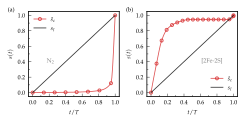

In [5]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.patheffects as patheffects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator
import matplotlib.image as mpimg
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size"  : 6
})

# Figure size: 2 columns × width_col, height = width_col/2 (in inches)
cm        = 1.0 / 2.54
width_col = 8.6 * cm
width     = width_col 
height    = width_col / 2
#plt.figure(figsize=(width,height),dpi=600)

# Create figure and 4 horizontal panels with default padding
fig, axes = plt.subplots(1, 2, figsize=(width, height),dpi=600)


marker_style_ref = dict(marker='',linestyle='dotted',color='gray',alpha=0.9,linewidth=0.4)

marker_style_1   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_p4   = dict(marker='o', markersize=3, linestyle='', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_sm   = dict(marker='o', markersize=3, linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_p   = dict(marker='o', markersize=2, linestyle='', color='tab:red', alpha=0.8,  fillstyle='none',mew=0.5)
marker_style_1_mark   = dict(marker='x', markersize=3.0, linestyle='', color='tab:red', alpha=1.0,  fillstyle='full',mew=0.7)
marker_style_1_l   = dict(marker='', linestyle='solid', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_1_ref = dict(marker='',linestyle='dashed',color='tab:red',alpha=0.8,linewidth=0.8)

marker_style_2   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_sm   = dict(marker='o', markersize=3, linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_p   = dict(marker='o', markersize=2, linestyle='', color='black', alpha=0.8,  fillstyle='none',mew=0.5)
marker_style_2_mark   = dict(marker='x', markersize=3.0, linestyle='', color='black', alpha=1.0,  fillstyle='full',mew=0.7)
marker_style_2_l   = dict(marker='', linestyle='solid', color='black', alpha=0.8,  fillstyle='none')
marker_style_2_ref = dict(marker='',linestyle='dashed',color='black',alpha=0.8,linewidth=0.8)

marker_style_3   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_sm   = dict(marker='o', markersize=3, linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_p   = dict(marker='o', markersize=2, linestyle='', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_l   = dict(marker='', linestyle='solid', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_ref   = dict(marker='', linestyle='dashed', color='mediumblue', alpha=0.8, linewidth=0.8)


# Work in panel (a) - schedule for N_2
axis = axes[0]
# interpolated schedule
from scipy.interpolate import PchipInterpolator

optimal_schedule = PchipInterpolator(t_list_N2, s_list_N2, extrapolate=True)



x_min    =  -0.05
x_max    =  +1.05

y_min    =  -0.05
y_max    =  +1.05


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.23, 1, r'(a)',transform=axis.transAxes)
#axis.text(0.15, 0.5, r'$R=3.0\AA$',transform=axis.transAxes,color='gray')
axis.set_xlabel(r'$t/T$')
axis.set_ylabel(r'$s(t)$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))


axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axis.plot(t_list_N2,s_list_N2, label ='', **marker_style_1_p4)
t_list_fine = np.linspace(0, 1, 101)
axis.plot(t_list_fine, optimal_schedule(t_list_fine), lw=0.8, label ='', **marker_style_1_l)
axis.plot(t_list_N2,[-1]*len(t_list_N2), label =r'$\hat{s}_c$', lw=0.8, **marker_style_1)

axis.plot(t_list_N2,t_list_N2, label =r'$s_l$', lw=0.8, **marker_style_2_l)
#axis.plot(t_list_fine, exact_optimal_schedule(t_list_fine), label =r'$s_o$', **marker_style_ref)

axis.text(0.20, 0.4, r'N$_2$',transform=axis.transAxes,color='gray')

axis.legend(loc='upper left',frameon=False)

# Work in panel (a) - schedule for N_2
axis = axes[1]
# interpolated schedule
from scipy.interpolate import PchipInterpolator

optimal_schedule = PchipInterpolator(t_list_FeS, s_list_FeS, extrapolate=True)



x_min    =  -0.05
x_max    =  +1.05

y_min    =  -0.05
y_max    =  +1.05


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.23, 1, r'(b)',transform=axis.transAxes)
#axis.text(0.15, 0.5, r'$R=3.0\AA$',transform=axis.transAxes,color='gray')
axis.set_xlabel(r'$t/T$')
axis.set_ylabel(r'$s(t)$')
# setup tics
axis.tick_params(axis='x', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='x', which='minor', direction='in', length=1.4, width=0.4)
axis.tick_params(axis='y', which='major', direction='in', length=2.8, width=0.4)
axis.tick_params(axis='y', which='minor', direction='in', length=1.4, width=0.4)
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))


axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axis.plot(t_list_FeS,s_list_FeS, label ='', **marker_style_1_p4)
t_list_fine = np.linspace(0, 1, 101)
axis.plot(t_list_fine, optimal_schedule(t_list_fine), lw=0.8, label ='', **marker_style_1_l)
axis.plot(t_list_FeS,[-1]*len(t_list_FeS), label =r'$\hat{s}_c$', lw=0.8, **marker_style_1)

axis.plot(t_list_FeS,t_list_FeS, label =r'$s_l$', lw=0.8, **marker_style_2_l)
#axis.plot(t_list_fine, exact_optimal_schedule(t_list_fine), label =r'$s_o$', **marker_style_ref)
axis.text(0.6, 0.4, r'[2Fe-2S]',transform=axis.transAxes,color='gray')

axis.legend(loc='lower right',frameon=False)






plt.tight_layout()
plt.savefig('figS1.pdf')